In [ ]:
!pip uninstall lz4 -y
!pip install lz4
!pip install lz4
!pip install mtcnn
!pip install librosa opencv-python tensorflow mtcnn matplotlib seaborn scikit-learn > /dev/null
!pip install lz4 librosa opencv-python tensorflow mtcnn matplotlib seaborn scikit-learn > /dev/null

Found existing installation: lz4 4.4.5
Uninstalling lz4-4.4.5:
  Successfully uninstalled lz4-4.4.5
  Using cached lz4-4.4.5-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (3.8 kB)
Using cached lz4-4.4.5-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (1.4 MB)


Procesando Neutral: 1089 archivos
Procesando Feliz: 1271 archivos
Procesando Triste: 1277 archivos
Procesando Enojado: 1277 archivos
Procesando Miedo: 1271 archivos
Datos finales: Visual (6185, 48, 48, 3), Audio (6185, 100, 40)
Iniciando entrenamiento...
Epoch 1/30
310/310 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.3050 - loss: 1.5204 - val_accuracy: 0.4559 - val_loss: 1.2728
Epoch 2/30
310/310 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4228 - loss: 1.3222 - val_accuracy: 0.4681 - val_loss: 1.2399
Epoch 3/30
310/310 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4542 - loss: 1.2589 - val_accuracy: 0.4802 - val_loss: 1.2224
Epoch 4/30
310/310 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4888 - loss: 1.2119 - val_accuracy: 0.5651 - val_loss: 1.0934
Epoch 5/30
310/310 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5682 - loss: 1.0514 - val_accuracy: 0.6176 - val_loss: 0.9603
Epoch 6/30
310/310 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6066 - loss: 0.9387 - val_accura

Mguardado: /content/drive/MyDrive/colab/Proyecto_IA/modelo_multimodal_final.h5

métricas
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

CLASIFICACIÓN
              precision    recall  f1-score   support

     Neutral       0.74      0.74      0.74       231
       Feliz       0.87      0.89      0.88       255
      Triste       0.61      0.65      0.63       245
     Enojado       0.84      0.71      0.77       265
       Miedo       0.56      0.60      0.58       241

    accuracy                           0.72      1237
   macro avg       0.72      0.72      0.72      1237
weighted avg       0.73      0.72      0.72      1237



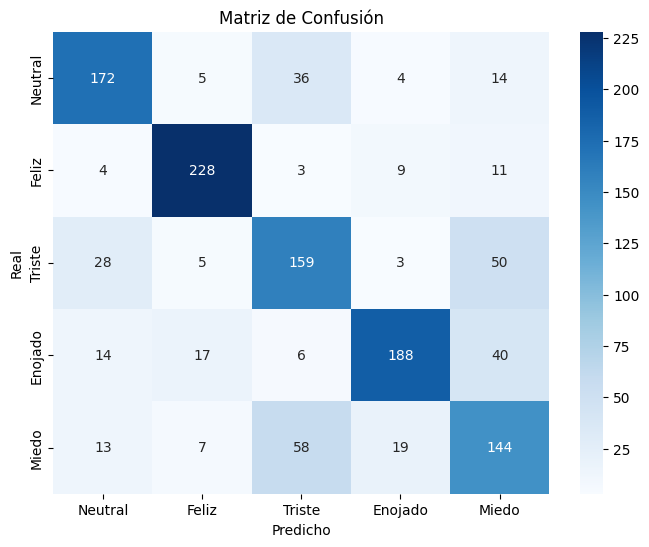

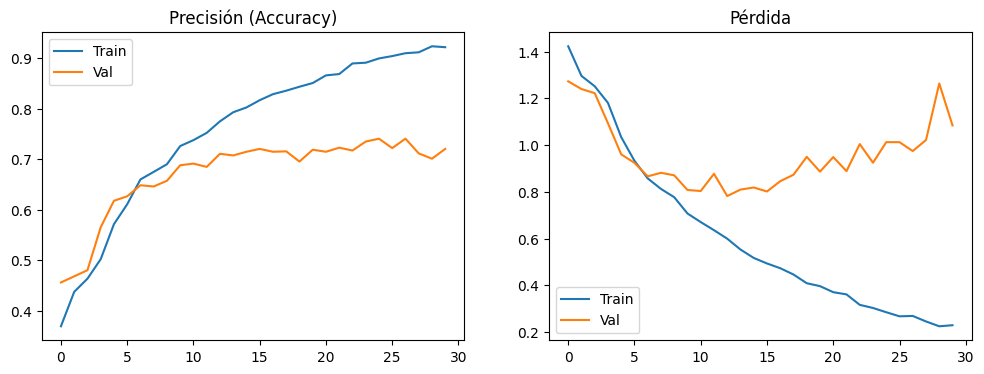

In [ ]:
import sys
import subprocess
import os
import cv2
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, LSTM, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from google.colab import drive
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. INSTALACIÓN Y CONFIGURACIÓN
try:
    import lz4
    import librosa
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lz4", "librosa", "opencv-python", "tensorflow", "scikit-learn"])

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/'
CLASS_LABELS = {'Neutral': 0, 'Feliz': 1, 'Triste': 2, 'Enojado': 3, 'Miedo': 4}
IMG_SIZE = (48, 48)
MAX_AUDIO_LEN = 100
N_MFCC = 40
MAX_PER_CLASS = 1500

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 2. FUNCIONES DE EXTRACCIÓN
def extract_visual_features(file_path):
    cap = cv2.VideoCapture(file_path)
    target_frame = None
    try:
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total > 0: cap.set(cv2.CAP_PROP_POS_FRAMES, total // 2)
        ret, frame = cap.read()

        if ret and frame is not None:
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            faces = face_cascade.detectMultiScale(gray, 1.1, 4)

            if len(faces) > 0:
                x, y, w, h = faces[0]
                face = frame[y:y+h, x:x+w]
                target_frame = cv2.resize(face, IMG_SIZE)
                target_frame = cv2.cvtColor(target_frame, cv2.COLOR_BGR2RGB)
            else:
                target_frame = cv2.resize(frame, IMG_SIZE)
                target_frame = cv2.cvtColor(target_frame, cv2.COLOR_BGR2RGB)
    except:
        pass
    finally:
        cap.release()

    if target_frame is None: return np.zeros((48,48,3))
    return target_frame / 255.0

def extract_audio_features(file_path):
    try:
        y, sr = librosa.load(file_path, duration=3.0, offset=0.5)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
        if mfccs.shape[1] > MAX_AUDIO_LEN:
            mfccs = mfccs[:, :MAX_AUDIO_LEN]
        else:
            mfccs = np.pad(mfccs, ((0,0), (0, MAX_AUDIO_LEN - mfccs.shape[1])))
        return mfccs.T
    except: return np.zeros((MAX_AUDIO_LEN, N_MFCC))

# 3. CARGA DE DATOS
X_v_raw, X_a_raw, y_raw = [], [], []

if os.path.exists(BASE_DIR):
    for label, idx in CLASS_LABELS.items():
        path = os.path.join(BASE_DIR, label)
        if not os.path.exists(path): continue

        files = [f for f in os.listdir(path) if f.lower().endswith(('.mp4','.avi','.mov','.flv','.mkv'))]
        files = files[:MAX_PER_CLASS]

        print(f"Procesando {label}: {len(files)} archivos")

        for f in files:
            fp = os.path.join(path, f)
            v = extract_visual_features(fp)
            a = extract_audio_features(fp)

            if np.any(v) or np.any(a):
                X_v_raw.append(v)
                X_a_raw.append(a)
                y_raw.append(idx)
else:
    print(f"Error de ruta: {BASE_DIR}")

# Limpieza de datos corruptos
X_v_clean = []
X_a_clean = []
y_clean = []

for i in range(len(X_v_raw)):
    if X_v_raw[i].shape == (48, 48, 3) and X_a_raw[i].shape == (100, 40):
        X_v_clean.append(X_v_raw[i])
        X_a_clean.append(X_a_raw[i])
        y_clean.append(y_raw[i])

X_v = np.array(X_v_clean, dtype='float32')
X_a = np.array(X_a_clean, dtype='float32')
y_encoded = to_categorical(np.array(y_clean), num_classes=5)

print(f"Datos finales: Visual {X_v.shape}, Audio {X_a.shape}")

# 4. ENTRENAMIENTO Y EVALUACIÓN
if len(X_v) > 0:
    X_v_train, X_v_test, X_a_train, X_a_test, y_train, y_test = train_test_split(X_v, X_a, y_encoded, test_size=0.2, random_state=42)

    # Definición del Modelo
    vin = Input((48,48,3))
    x1 = Conv2D(32,(3,3),activation='relu')(vin)
    x1 = MaxPooling2D((2,2))(x1)
    x1 = Flatten()(MaxPooling2D((2,2))(Conv2D(64,(3,3),activation='relu')(x1)))
    x1 = Dense(64, activation='relu')(x1)

    ain = Input((100,40))
    x2 = Dense(64, activation='relu')(Dropout(0.3)(LSTM(128)(ain)))

    merged = Concatenate()([x1, x2])
    out = Dense(5, activation='softmax')(Dropout(0.4)(Dense(64, activation='relu')(merged)))

    model = Model([vin, ain], out)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    print("Iniciando entrenamiento...")

    history = model.fit([X_v_train, X_a_train], y_train,
                        validation_data=([X_v_test, X_a_test], y_test),
                        epochs=30,
                        batch_size=16)

    # Guardamos el modelo
    save_path = '/content/drive/MyDrive/colab/Proyecto_IA/modelo_multimodal_final.h5'
    model.save(save_path)
    print(f"Mguardado: {save_path}")

    #EVALUACIÓN Y GRÁFICAS
    print("\nmétricas")

    # 1. Predicciones
    y_pred_raw = model.predict([X_v_test, X_a_test])
    y_pred_classes = np.argmax(y_pred_raw, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)

    # 2. Reporte
    print("\nCLASIFICACIÓN")
    print(classification_report(y_true_classes, y_pred_classes, target_names=list(CLASS_LABELS.keys())))

    # 3. Matriz de Confusión
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_LABELS.keys(),
                yticklabels=CLASS_LABELS.keys())
    plt.title('Matriz de Confusión')
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.show()

    # 4. Gráficas de Entrenamiento
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title('Precisión (Accuracy)')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title('Pérdida')
    plt.legend()
    plt.show()

else:
    print("mas datos w")

In [1]:
!pip install lz4 mtcnn librosa opencv-python tensorflow > /dev/null
import os
import numpy as np
import cv2
import librosa
from mtcnn import MTCNN
from tensorflow.keras.models import load_model
from google.colab import files, drive


if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

possible_paths = [
    'modelo_multimodal_final.h5',
    '/content/modelo_multimodal_final.h5',
    '/content/drive/MyDrive/colab/Proyecto_IA/modelo_multimodal_final.h5',
    '/content/drive/MyDrive/modelo_multimodal_final.h5'
]

model = None
model_path_found = None

for path in possible_paths:
    if os.path.exists(path):
        print(f"encontrado: {path}")
        model_path_found = path
        break

if model_path_found:
    try:
        model = load_model(model_path_found)
        print("Modelo cargado")
    except Exception as e:
        print(f" error: {e}")
else:
    print("\nerror como siempre")



if model is not None:
    # Configuración
    IMG_SIZE = (48, 48)
    MAX_AUDIO_LEN = 100
    N_MFCC = 40
    EMOTION_MAP = {0: 'Neutral', 1: 'Feliz', 2: 'Triste', 3: 'Enojado', 4: 'Miedo'}
    detector = MTCNN()

    def prepare_video(file_path):
        cap = cv2.VideoCapture(file_path)
        visual_input = None
        try:
            total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            if total > 0: cap.set(cv2.CAP_PROP_POS_FRAMES, total // 2)
            ret, frame = cap.read()
            if ret:
                results = detector.detect_faces(frame)
                if results:
                    x, y, w, h = results[0]['box']
                    face = frame[max(0,y):y+h, max(0,x):x+w]
                    face = cv2.resize(face, IMG_SIZE)
                    visual_input = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
                else:
                    visual_input = cv2.cvtColor(cv2.resize(frame, IMG_SIZE), cv2.COLOR_BGR2RGB)
        except: pass
        finally: cap.release()

        if visual_input is None: visual_input = np.zeros((48,48,3))

        # Audio
        audio_input = np.zeros((MAX_AUDIO_LEN, N_MFCC))
        try:
            y, sr = librosa.load(file_path, duration=3.0, offset=0.5)
            mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
            if mfccs.shape[1] > MAX_AUDIO_LEN: mfccs = mfccs[:, :MAX_AUDIO_LEN]
            else: mfccs = np.pad(mfccs, ((0,0), (0, MAX_AUDIO_LEN - mfccs.shape[1])))
            audio_input = mfccs.T
        except: pass

        return np.expand_dims(visual_input/255.0, 0), np.expand_dims(audio_input, 0)

    print("\nsubelo el archivo")
    uploaded = files.upload()
    for fn in uploaded.keys():
        print(f"Espere {fn}...")
        v, a = prepare_video(fn)
        pred = model.predict([v, a])
        idx = np.argmax(pred)
        print(f"\nEmoción: {EMOTION_MAP[idx].upper()} ({np.max(pred)*100:.1f}%)")

Mounted at /content/drive
encontrado: /content/drive/MyDrive/colab/Proyecto_IA/modelo_multimodal_final.h5


Modelo cargado

subelo el archivo


Saving 1001_DFA_HAP_XX.flv to 1001_DFA_HAP_XX.flv
Espere 1001_DFA_HAP_XX.flv...


/tmp/ipykernel_17197/2530343058.py:73: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, duration=3.0, offset=0.5)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Emoción: FELIZ (100.0%)
